In [69]:
import os
import pandas as pd

# First see all files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/README.md
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/stats-dataset.json
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/stats-week.json
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/6_Sat/flows-20221105.csv
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/6_Sat/stats-20221105.json
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/7_Sun/stats-20221106.json
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/7_Sun/flows-20221106.csv
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/2_Tue/flows-20221101.csv
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/2_Tue/stats-20221101.json
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/1_Mon/flows-20221031.csv
/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/1_Mon/stats-2022

In [70]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/zilinpeng/cesnet-quic22/cesnet-quic22/W-2022-44/1_Mon/flows-20221031.csv')

df = df.groupby('CATEGORY').apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"\nCategory distribution:\n{df['CATEGORY'].value_counts()}")

/tmp/ipykernel_96/1345660581.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('CATEGORY').apply(


Total rows: 52741

Category distribution:
CATEGORY
Advertising                3000
Analytics & Telemetry      3000
Antivirus                  3000
Authentication services    3000
Blogs & News               3000
E-commerce                 3000
File sharing               3000
Games                      3000
Information systems        3000
Instant messaging          3000
Mail                       3000
Music                      3000
Other services and APIs    3000
Search                     3000
Social                     3000
Streaming media            3000
default                    3000
Videoconferencing          1741
Name: count, dtype: int64


In [71]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import ast

# Remove "default" category - it's a catch-all that hurts accuracy
df = df[df['CATEGORY'] != 'default'].copy()
print(f"After removing default: {len(df)} rows")

feature_cols = [
    'DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV',
    'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS',
    'FLOW_ENDREASON_IDLE', 'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER'
]

df['FLOW_ENDREASON_IDLE'] = df['FLOW_ENDREASON_IDLE'].astype(int)
df['FLOW_ENDREASON_ACTIVE'] = df['FLOW_ENDREASON_ACTIVE'].astype(int)
df['FLOW_ENDREASON_OTHER'] = df['FLOW_ENDREASON_OTHER'].astype(int)

# Derived features (RTT proxy, jitter proxy, byte ratios)
df['BYTES_RATIO'] = df['BYTES'] / (df['BYTES_REV'] + 1)
df['PACKET_SIZE_MEAN'] = df['BYTES'] / (df['PACKETS'] + 1)
df['PACKET_SIZE_REV_MEAN'] = df['BYTES_REV'] / (df['PACKETS_REV'] + 1)
df['FLOW_RATE'] = df['BYTES'] / (df['DURATION'] + 1e-6)
df['PACKET_RATE'] = df['PACKETS'] / (df['DURATION'] + 1e-6)
df['RTT_PROXY'] = df['PPI_DURATION'] / (df['PPI_ROUNDTRIPS'] + 1)

feature_cols += [
    'BYTES_RATIO', 'PACKET_SIZE_MEAN', 'PACKET_SIZE_REV_MEAN',
    'FLOW_RATE', 'PACKET_RATE', 'RTT_PROXY'
]

# 5-tuple features
df['SRC_PORT_NORM'] = df['SRC_PORT'] / 65535.0
df['DST_PORT_NORM'] = df['DST_PORT'] / 65535.0
df['PROTOCOL_NORM'] = df['PROTOCOL'] / 255.0

# Jitter proxy (variation in inter-arrival times)
def parse_hist(val):
    try:
        arr = ast.literal_eval(val)
        return np.array(arr, dtype=float)
    except:
        return np.zeros(8)

# Jitter = std of inter-arrival times
df['JITTER_SRC'] = df['PHIST_SRC_IPT'].apply(
    lambda x: np.std(parse_hist(x))
)
df['JITTER_DST'] = df['PHIST_DST_IPT'].apply(
    lambda x: np.std(parse_hist(x))
)

feature_cols += [
    'SRC_PORT_NORM', 'DST_PORT_NORM', 'PROTOCOL_NORM',
    'JITTER_SRC', 'JITTER_DST'
]

# Extract histogram features
def parse_hist(val):
    try:
        arr = ast.literal_eval(val)
        return np.array(arr, dtype=float)
    except:
        return np.zeros(8)

print("Extracting histogram features...")
for col in ['PHIST_SRC_SIZES', 'PHIST_DST_SIZES', 'PHIST_SRC_IPT', 'PHIST_DST_IPT']:
    hist_vals = df[col].apply(parse_hist)
    hist_df = pd.DataFrame(hist_vals.tolist(),
                           columns=[f'{col}_{i}' for i in range(8)],
                           index=df.index)
    df = pd.concat([df, hist_df], axis=1)
    feature_cols += [f'{col}_{i}' for i in range(8)]

print(f"Total features: {len(feature_cols)}")

df = df.dropna(subset=feature_cols)

# Sample per category
df = df.groupby('CATEGORY').apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(f"\nSamples per category:\n{df['CATEGORY'].value_counts()}")

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['CATEGORY'])

X = df[feature_cols].values
y = df['label_encoded'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nClasses: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

After removing default: 49741 rows
Extracting histogram features...
Total features: 54

Samples per category:
CATEGORY
Advertising                3000
Analytics & Telemetry      3000
Antivirus                  3000
Authentication services    3000
Blogs & News               3000
E-commerce                 3000
File sharing               3000
Games                      3000
Information systems        3000
Instant messaging          3000
Mail                       3000
Music                      3000
Other services and APIs    3000
Search                     3000
Social                     3000
Streaming media            3000
Videoconferencing          1741
Name: count, dtype: int64

Classes: ['Advertising' 'Analytics & Telemetry' 'Antivirus'
 'Authentication services' 'Blogs & News' 'E-commerce' 'File sharing'
 'Games' 'Information systems' 'Instant messaging' 'Mail' 'Music'
 'Other services and APIs' 'Search' 'Social' 'Streaming media'
 'Videoconferencing']
Number of classes: 17
Trainin

/tmp/ipykernel_96/1622996722.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('CATEGORY').apply(


In [72]:
import torch
import torch.nn as nn

class TransformerFlowEncoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, nhead=4, num_layers=2):
        super(TransformerFlowEncoder, self).__init__()
        
        # Project input features to a dimension divisible by nhead
        self.input_proj = nn.Linear(input_dim, 64)
        
        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=nhead,         # 4 attention heads
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers  # 2 transformer layers
        )
        
        # Final projection to embedding
        self.output_proj = nn.Sequential(
            nn.Linear(64, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )
    
    def forward(self, x):
        # x shape: [batch, features]
        # Transformer expects [batch, seq_len, features]
        # We treat each feature as a sequence element
        x = self.input_proj(x)          # [batch, 64]
        x = x.unsqueeze(1)              # [batch, 1, 64]
        x = self.transformer(x)         # [batch, 1, 64]
        x = x.squeeze(1)               # [batch, 64]
        x = self.output_proj(x)         # [batch, 128]
        return nn.functional.normalize(x, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = TransformerFlowEncoder(
    input_dim=X_train.shape[1], 
    embedding_dim=128
).to(device)

print(f"Using: {device}")
print(f"Model parameters: {sum(p.numel() for p in encoder.parameters()):,}")
print(encoder)

Using: cuda
Model parameters: 128,320
TransformerFlowEncoder(
  (input_proj): Linear(in_features=54, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)


In [73]:
from torch.utils.data import TensorDataset, DataLoader

class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):  # lower temp = sharper separation
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings, labels):
        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        labels = labels.unsqueeze(1)
        mask = torch.eq(labels, labels.T).float().to(embeddings.device)
        identity = torch.eye(embeddings.size(0)).to(embeddings.device)
        mask = mask - identity
        exp_sim = torch.exp(sim_matrix)
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True))
        loss = -(mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return loss.mean()

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)

loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=256, shuffle=True
)

# Cosine annealing scheduler reduces LR gradually = better convergence
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100
)

print("Training Transformer encoder...")
for epoch in range(100):
    encoder.train()
    total_loss = 0
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        loss = criterion(encoder(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {total_loss/len(loader):.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

print("\nTraining done!")

Training Transformer encoder...
Epoch 20/100 | Loss: 4.5966 | LR: 0.000905
Epoch 40/100 | Loss: 4.4788 | LR: 0.000655
Epoch 60/100 | Loss: 4.4080 | LR: 0.000345
Epoch 80/100 | Loss: 4.3553 | LR: 0.000095
Epoch 100/100 | Loss: 4.3390 | LR: 0.000000

Training done!


In [74]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

encoder.eval()
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    train_embeddings = encoder(X_train_tensor).cpu().numpy()
    test_embeddings = encoder(X_test_tensor).cpu().numpy()

print("Training MLP classifier...")
classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,    # stops if no improvement
    validation_fraction=0.1,
    verbose=True
)
classifier.fit(train_embeddings, y_train)

y_pred = classifier.predict(test_embeddings)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training MLP classifier...
Iteration 1, loss = 1.00146309
Validation score: 0.782915
Iteration 2, loss = 0.68212636
Validation score: 0.773618
Iteration 3, loss = 0.67401429
Validation score: 0.773869
Iteration 4, loss = 0.67017062
Validation score: 0.773618
Iteration 5, loss = 0.66645921
Validation score: 0.785427
Iteration 6, loss = 0.66090415
Validation score: 0.782161
Iteration 7, loss = 0.65932419
Validation score: 0.781407
Iteration 8, loss = 0.65784699
Validation score: 0.783920
Iteration 9, loss = 0.65351899
Validation score: 0.786683
Iteration 10, loss = 0.65106682
Validation score: 0.779397
Iteration 11, loss = 0.65044658
Validation score: 0.784925
Iteration 12, loss = 0.64864984
Validation score: 0.781658
Iteration 13, loss = 0.64622078
Validation score: 0.781910
Iteration 14, loss = 0.64589750
Validation score: 0.781910
Iteration 15, loss = 0.64459200
Validation score: 0.784171
Iteration 16, loss = 0.64300427
Validation score: 0.783920
Iteration 17, loss = 0.64014115
Valida

In [75]:
from sklearn.ensemble import RandomForestClassifier

classifier_rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)
classifier_rf.fit(train_embeddings, y_train)
y_pred_rf = classifier_rf.predict(test_embeddings)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

Random Forest Accuracy: 69.20%


In [76]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import time

# Cosine similarity KPIs
class_embeddings = {}
for class_idx in np.unique(y_test):
    mask = y_test == class_idx
    class_embeddings[class_idx] = test_embeddings[mask]

intra_sims = []
for cls, embs in class_embeddings.items():
    if len(embs) > 1:
        sim = cosine_similarity(embs)
        upper = sim[np.triu_indices(len(sim), k=1)]
        intra_sims.extend(upper[:100])

inter_sims = []
classes = list(class_embeddings.keys())
for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        sim = cosine_similarity(
            class_embeddings[classes[i]][:50],
            class_embeddings[classes[j]][:50]
        )
        inter_sims.extend(sim.flatten())

print(f"Avg Intra-class similarity: {np.mean(intra_sims):.3f} (target >0.7)")
print(f"Avg Inter-class similarity: {np.mean(inter_sims):.3f} (target <0.3)")

# Inference time
single = X_test_tensor[0:1]
start = time.time()
with torch.no_grad():
    _ = encoder(single)
end = time.time()
print(f"Inference time: {(end-start)*1000:.2f} ms (target <100ms)")

Avg Intra-class similarity: 0.766 (target >0.7)
Avg Inter-class similarity: -0.030 (target <0.3)
Inference time: 1.91 ms (target <100ms)


Generating t-SNE plot...


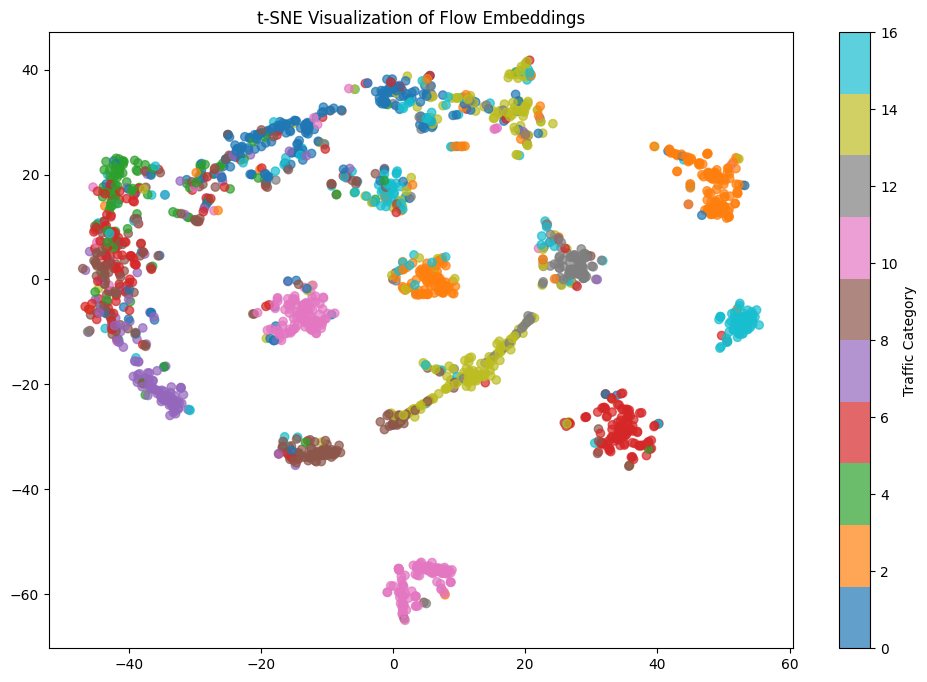

Done!


In [77]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Generating t-SNE plot...")
sample_idx = np.random.choice(len(test_embeddings), 
                               min(2000, len(test_embeddings)), 
                               replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(test_embeddings[sample_idx])

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=y_test[sample_idx], cmap='tab10', alpha=0.7
)
plt.colorbar(scatter, label='Traffic Category')
plt.title('t-SNE Visualization of Flow Embeddings')
plt.savefig('tsne_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [79]:
import pickle

torch.save(encoder.state_dict(), '/kaggle/working/flow_encoder.pth')
pickle.dump(classifier, open('/kaggle/working/classifier.pkl', 'wb'))
pickle.dump(scaler, open('/kaggle/working/scaler.pkl', 'wb'))
pickle.dump(le, open('/kaggle/working/label_encoder.pkl', 'wb'))

print("All models saved to /kaggle/working/")

All models saved to /kaggle/working/
